# 5 pacientes con β-talasemia, 23 meses sin transfusiones

Tres de ellos no producen ni una molécula de hemoglobina adulta. Su sangre es 100% fetal — y aun así viven sin transfusiones.

**Paper:** [Clinical application of base editing for treating β-thalassaemia](https://doi.org/10.1038/s41586-026-10342-9) · *Nature*, Lai et al. (2026) · NCT06024876

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-08-edicion-bases-beta-talasemia-clinico/notebook.ipynb)

🎬 **Video:** [Pendiente]

## Contexto

La β-talasemia rompe la receta de la β-globina, una de las dos cadenas de la hemoglobina adulta (HbA = 2α + 2β). Sin β, la sangre no transporta oxígeno y la única salida en pacientes severos son transfusiones de por vida.

Pero el cuerpo guarda un plan B: la **hemoglobina fetal (HbF)**, que usa γ-globina en lugar de β-globina. Funciona perfecto antes de nacer, pero un represor llamado *BCL11A* la apaga después del primer año de vida.

Los autores diseñaron un **base editor** (un editor de bases que cambia letras del ADN sin cortar la doble hélice) para desactivar el sitio donde BCL11A se ata al promotor de los genes γ. La idea: que el cuerpo vuelva a producir HbF como cuando estabas en el útero.

Este es el reporte del trial Fase 1 (CS-101): tomaron células madre de 5 pacientes, las editaron en un laboratorio, y se las re-infundieron tras destruir su médula con busulfán. Aquí están los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HBF_ADULTO_SANO_PCT = 1.0       # HbF normal en adulto: <1% de Hb total
HB_NORMAL_MIN = 12.0            # g/dl, umbral inferior normal hombre/mujer
COLOR_HBF = '#2563EB'           # Hemoglobina fetal — azul CaM
COLOR_HBA = '#DC2626'           # Hemoglobina adulta — rojo (la que falla)
COLOR_REF = '#D97706'           # Referencia — amber
COLOR_BETA0 = '#7C3AED'         # Pacientes β0/β0 — violeta
COLOR_BETA_PLUS = '#059669'     # Pacientes β+ (con algo de β residual) — verde
FUENTE = 'Fuente: Lai et al. (2026), Nature | Datos: Source Data MOESM3/6/11/13'

import os, json, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Cargar estilo CaM (local → fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar los 4 datasets verificados
df_invitro = pd.read_csv('datos/eficiencia_edicion_invitro.csv')
df_pbmc = pd.read_csv('datos/edicion_pbmc_temporal.csv')
df_hb = pd.read_csv('datos/hemoglobina_temporal.csv')
df_globinas = pd.read_csv('datos/globinas_periferica.csv')

# Clasificar pacientes por genotipo (β0/β0 = sin β residual; β+ = algo de β)
GENOTIPO = {'P1': 'β0/β0', 'P2': 'β+', 'P3': 'β+', 'P4': 'β0/β0', 'P5': 'β0/β0'}

print(f'In vitro: {len(df_invitro)} mediciones ({df_invitro.condicion.nunique()} condiciones × 5 réplicas)')
print(f'PBMC temporal: {len(df_pbmc)} mediciones (5 pacientes × {df_pbmc.month.nunique()} meses)')
print(f'Hemoglobina: {len(df_hb)} mediciones (5 pacientes × {df_hb.month.nunique()} meses)')
print(f'Globinas peripheral: {len(df_globinas)} pacientes')
print()
print('Genotipos:', GENOTIPO)
print('Pacientes β0/β0 (sin β-globina endógena):', [p for p,g in GENOTIPO.items() if g=='β0/β0'])

In vitro: 10 mediciones (2 condiciones × 5 réplicas)
PBMC temporal: 76 mediciones (5 pacientes × 16 meses)
Hemoglobina: 79 mediciones (5 pacientes × 17 meses)
Globinas peripheral: 5 pacientes

Genotipos: {'P1': 'β0/β0', 'P2': 'β+', 'P3': 'β+', 'P4': 'β0/β0', 'P5': 'β0/β0'}
Pacientes β0/β0 (sin β-globina endógena): ['P1', 'P4', 'P5']


## Aquí está.

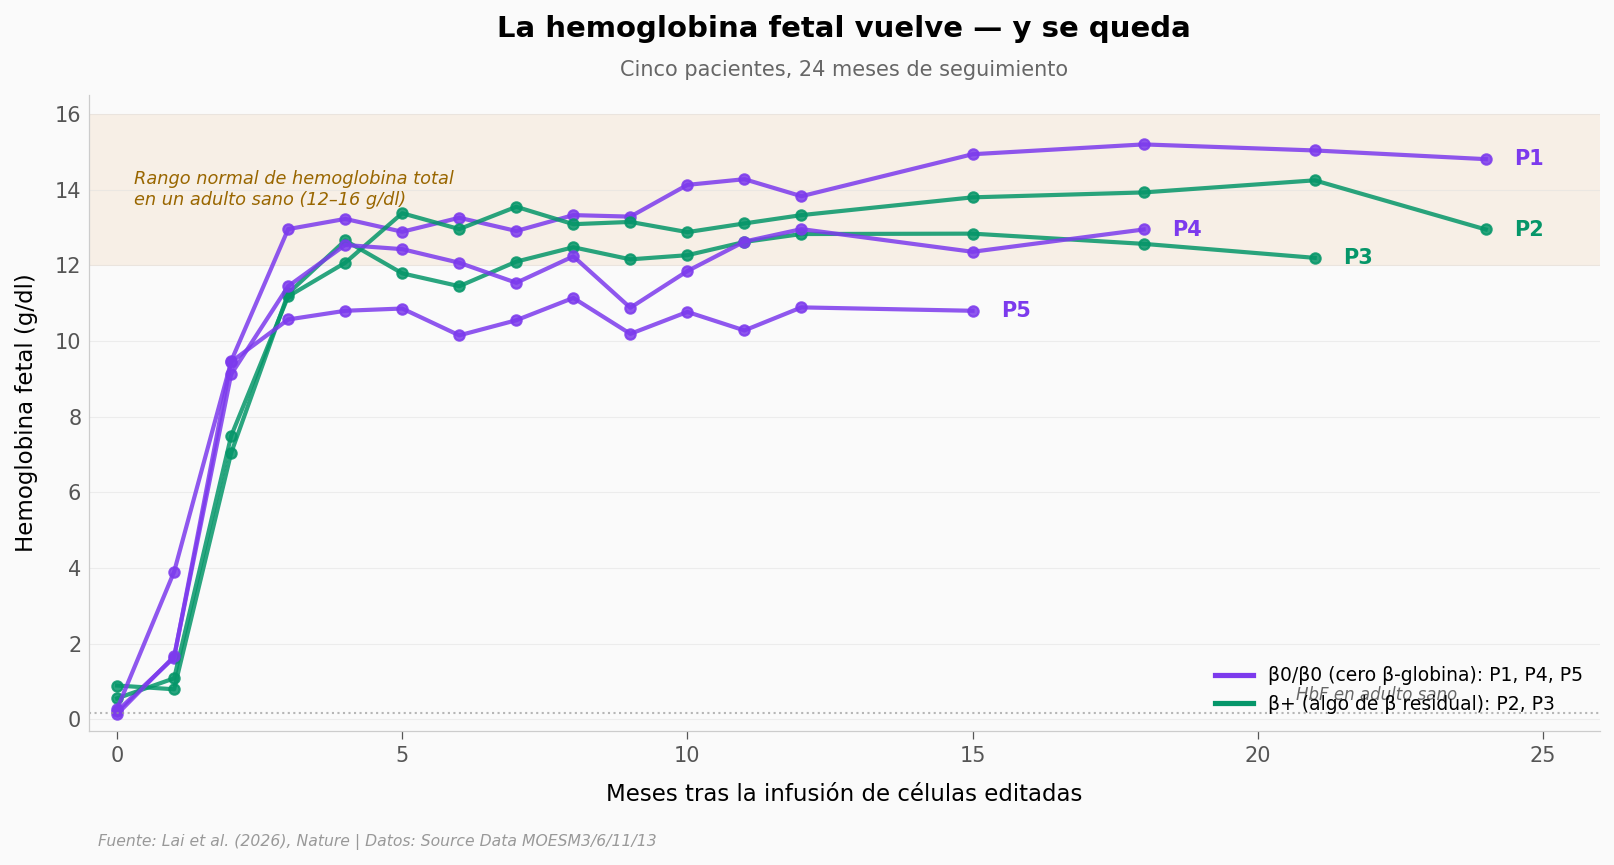

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Una línea por paciente, color por genotipo
for paciente in sorted(df_hb.patient.unique()):
    sub = df_hb[df_hb.patient == paciente].sort_values('month')
    color = COLOR_BETA0 if GENOTIPO[paciente] == 'β0/β0' else COLOR_BETA_PLUS
    ax.plot(sub.month, sub.hbf_g_dl, color=color, linewidth=2.0,
            marker='o', markersize=5, alpha=0.85)
    # Etiqueta inline al final de cada línea
    ult = sub.iloc[-1]
    ax.text(ult.month + 0.5, ult.hbf_g_dl, paciente,
            color=color, fontsize=10, fontweight='bold', va='center')

# Banda de referencia: rango normal de Hb total adulto sano
ax.axhspan(12, 16, alpha=0.08, color=COLOR_REF, zorder=0)
ax.text(0.3, 14.0, 'Rango normal de hemoglobina total\nen un adulto sano (12–16 g/dl)',
        fontsize=8.5, color='#996600', style='italic', va='center')

# Línea baseline pre-tratamiento (HbF en adulto sano: <1% del total ≈ <0.15 g/dl)
ax.axhline(y=0.15, color='#999999', linewidth=1, linestyle=':', alpha=0.7)
ax.text(23.5, 0.5, 'HbF en adulto sano',
        fontsize=8, color='#666666', style='italic', ha='right')

ax.set_xlabel('Meses tras la infusión de células editadas', fontsize=11)
ax.set_ylabel('Hemoglobina fetal (g/dl)', fontsize=11)
ax.set_title('La hemoglobina fetal vuelve — y se queda',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cinco pacientes, 24 meses de seguimiento',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.5, 26)
ax.set_ylim(-0.3, 16.5)

# Leyenda de genotipos (inline, abajo izquierda)
leyenda = [Line2D([0],[0], color=COLOR_BETA0, lw=2.5, label='β0/β0 (cero β-globina): P1, P4, P5'),
           Line2D([0],[0], color=COLOR_BETA_PLUS, lw=2.5, label='β+ (algo de β residual): P2, P3')]
ax.legend(handles=leyenda, loc='lower right', fontsize=9, framealpha=0.95)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_hbf_temporal.png', dpi=200, bbox_inches='tight')
plt.show()

Antes del tratamiento, los 5 pacientes vivían con HbF cercana a cero. En las primeras 12 semanas todos cruzaron los 12 g/dl — el umbral inferior de la zona normal en un adulto sano. La diferencia entre genotipos no se ve en este corte: P1, P4 y P5 (β0/β0, sin β-globina endógena) suben igual que P2 y P3 (β+).

La pregunta es por qué se queda. Las células madre normales se renuevan toda la vida; si el editor cambió el ADN de las células madre verdaderas, sus descendientes heredan la edición. Si solo cambió células ya diferenciadas (que no se replican), el efecto se desvanece en meses.

Veamos primero si el base editor funcionaba en el banco antes de tocar a un paciente.

## Antes del trial: ¿funciona en el laboratorio?

Cinco lotes de células CD34+ (madre hematopoyéticas) editadas en paralelo, con un control no-tratado por lote. Esto es el *go/no-go* preclínico: si el background es alto o la edición es errática, el trial no arranca.

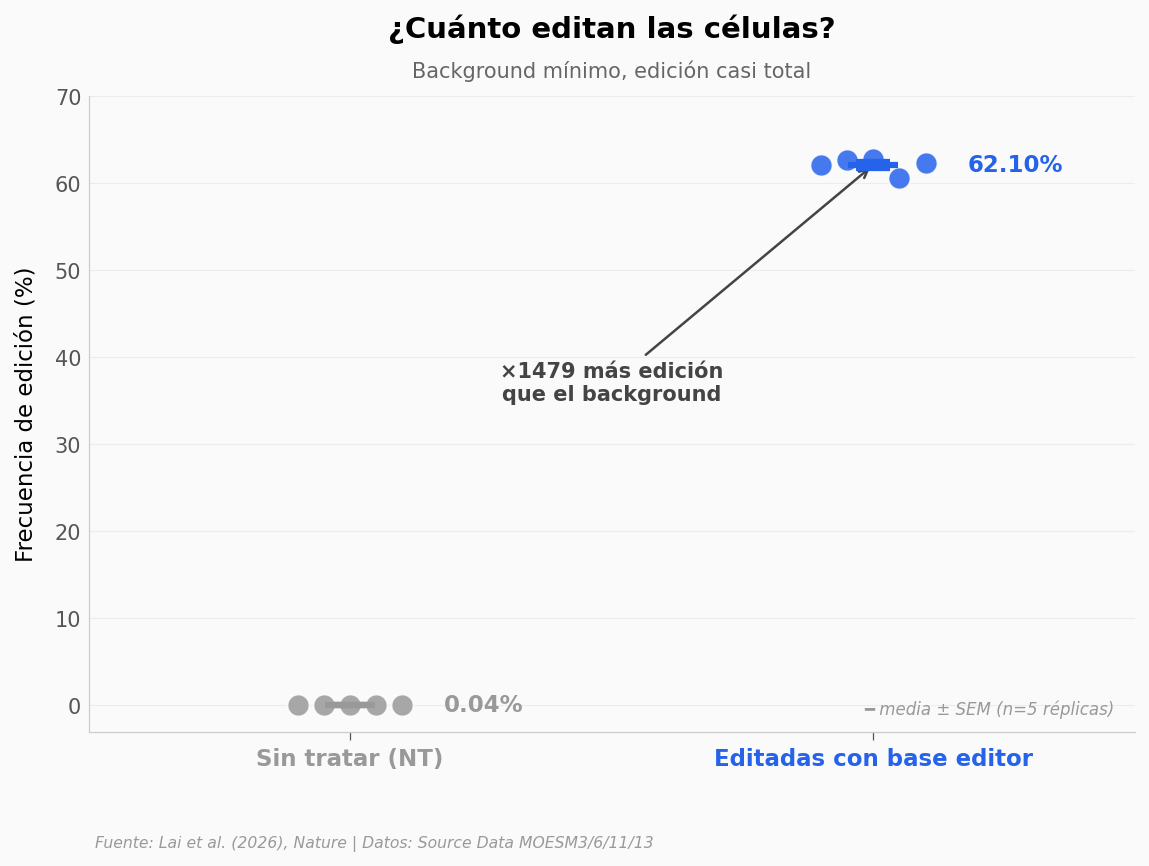

Wilcoxon signed-rank (pareado, unilateral): W=15.0, p=0.0312
Cohen's dz pareado = 68.7 (umbral grande: d≥0.8)
Ratio editadas/NT: ×1479


In [3]:
np.random.seed(42)  # jitter reproducible
fig, ax = plt.subplots(figsize=(9, 5.5))

condiciones = ['NT_CD34_HSPCs', 'Editadas_CD34_HSPCs']
labels = ['Sin tratar (NT)', 'Editadas con base editor']
colores = ['#999999', COLOR_HBF]
positions = [0, 1]

for pos, cond, color, lab in zip(positions, condiciones, colores, labels):
    vals = df_invitro[df_invitro.condicion == cond].editing_freq_pct.values
    n = len(vals)
    x_strip = np.linspace(pos - 0.10, pos + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=110, alpha=0.85,
               edgecolors='white', linewidths=0.8, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, media, yerr=sem, fmt='_', color=color,
                markersize=24, markeredgewidth=3,
                capsize=8, capthick=1.8, zorder=6)
    # Anotar la media exacta
    ax.text(pos + 0.18, media, f'{media:.2f}%',
            color=color, fontsize=11, fontweight='bold', va='center')

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores):
    tick.set_color(color)

ax.set_ylabel('Frecuencia de edición (%)', fontsize=11)
ax.set_title('¿Cuánto editan las células?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Background mínimo, edición casi total',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-3, 70)

# Anotación dramática: el ratio
media_nt = df_invitro[df_invitro.condicion=='NT_CD34_HSPCs'].editing_freq_pct.mean()
media_ed = df_invitro[df_invitro.condicion=='Editadas_CD34_HSPCs'].editing_freq_pct.mean()
ratio = media_ed / media_nt
ax.annotate(f'×{ratio:.0f} más edición\nque el background',
            xy=(1, media_ed), xytext=(0.5, 35),
            fontsize=10, color='#444444', ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#444444', lw=1.2))

ax.text(0.98, 0.02, '━ media ± SEM (n=5 réplicas)',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/invitro_nt_vs_editadas.png', dpi=200, bbox_inches='tight')
plt.show()

# Test estadístico — réplicas pareadas por lote
# (la réplica 1, 2, 3, 4, 5 es el MISMO lote de CD34+ dividido en NT vs Editadas)
from scipy import stats
nt_sorted = df_invitro[df_invitro.condicion=='NT_CD34_HSPCs'].sort_values('replica').editing_freq_pct.values
ed_sorted = df_invitro[df_invitro.condicion=='Editadas_CD34_HSPCs'].sort_values('replica').editing_freq_pct.values
w_stat, p_val = stats.wilcoxon(ed_sorted, nt_sorted, alternative='greater')
diff = ed_sorted - nt_sorted
cohens_dz = diff.mean() / diff.std(ddof=1)
print(f'Wilcoxon signed-rank (pareado, unilateral): W={w_stat:.1f}, p={p_val:.4f}')
print(f'Cohen\'s dz pareado = {cohens_dz:.1f} (umbral grande: d≥0.8)')
print(f'Ratio editadas/NT: ×{ratio:.0f}')

## ¿Y dentro del cuerpo?

In vitro convirtieron 4 alelos por cada 10.000 (background) en 6 de cada 10 (edición). Pero un base editor que funciona en una placa de Petri no garantiza nada: las células editadas tienen que sobrevivir el viaje a la médula, anidar, multiplicarse, y llegar a la sangre. Si los datos del cuerpo se desploman con el tiempo, el editor solo tocó células de corta vida.

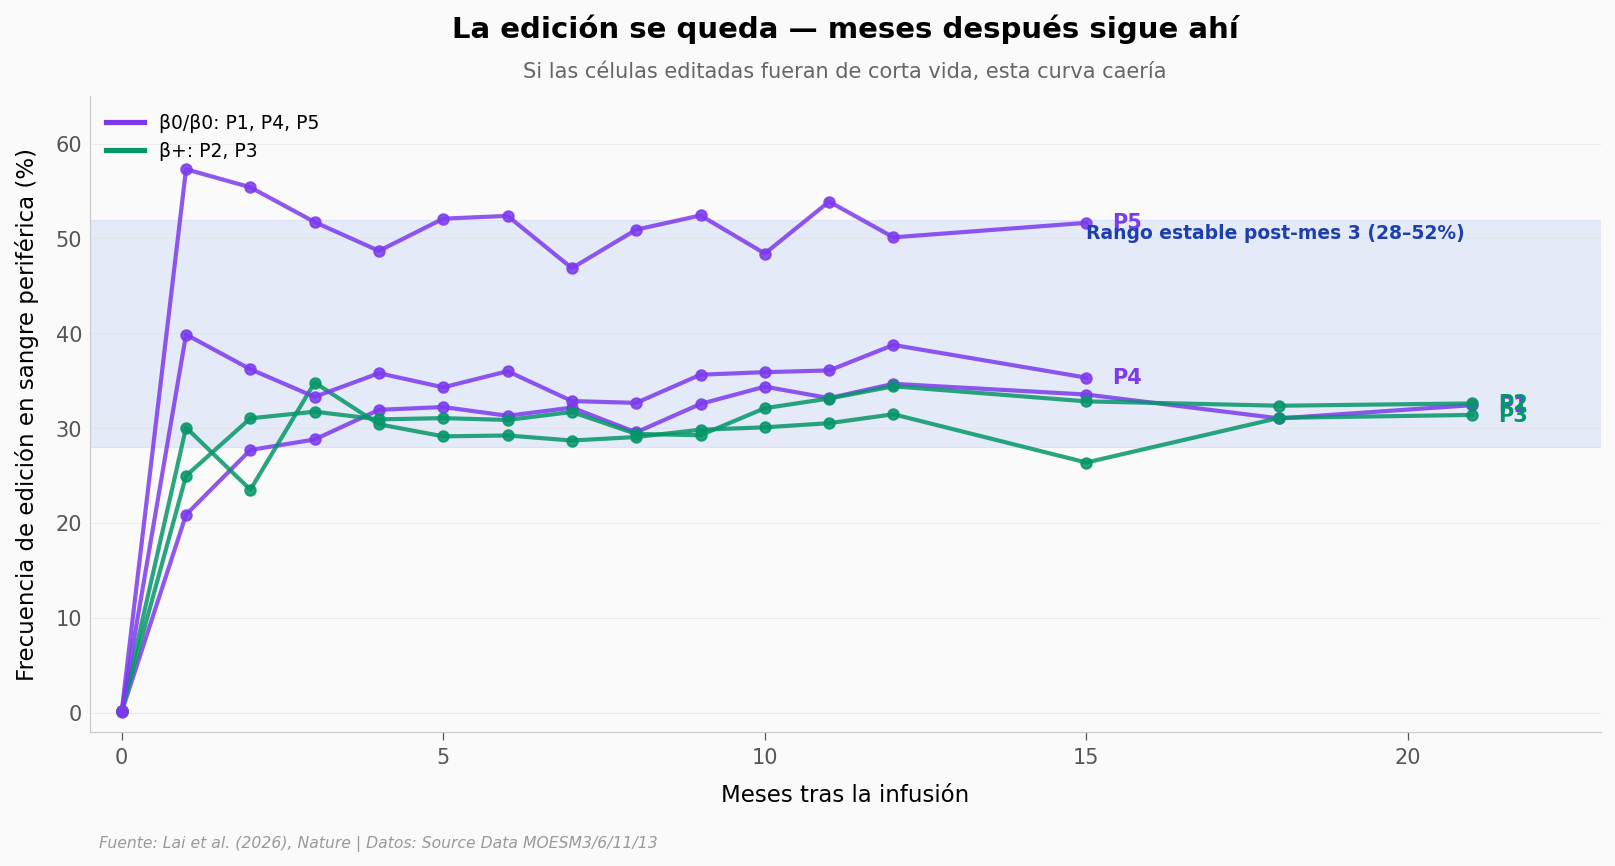

Edición a 12 meses (n=5):
patient  editing_freq_pct
     P1             34.67
     P2             34.41
     P3             31.46
     P4             38.77
     P5             50.12

Media: 37.89% · DE: 7.32%


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Una línea por paciente
for paciente in sorted(df_pbmc.patient.unique()):
    sub = df_pbmc[df_pbmc.patient == paciente].sort_values('month')
    color = COLOR_BETA0 if GENOTIPO[paciente] == 'β0/β0' else COLOR_BETA_PLUS
    ax.plot(sub.month, sub.editing_freq_pct, color=color, linewidth=2.0,
            marker='o', markersize=5, alpha=0.85)
    ult = sub.iloc[-1]
    ax.text(ult.month + 0.4, ult.editing_freq_pct, paciente,
            color=color, fontsize=10, fontweight='bold', va='center')

# Banda de estabilización 28-52% (rango observado post-3M)
ax.axhspan(28, 52, alpha=0.10, color='#2563EB', zorder=0)
ax.text(15, 50, 'Rango estable post-mes 3 (28–52%)',
        fontsize=9, color='#1E40AF', fontweight='bold')

ax.set_xlabel('Meses tras la infusión', fontsize=11)
ax.set_ylabel('Frecuencia de edición en sangre periférica (%)', fontsize=11)
ax.set_title('La edición se queda — meses después sigue ahí',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Si las células editadas fueran de corta vida, esta curva caería',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.5, 23)
ax.set_ylim(-2, 65)

leyenda = [Line2D([0],[0], color=COLOR_BETA0, lw=2.5, label='β0/β0: P1, P4, P5'),
           Line2D([0],[0], color=COLOR_BETA_PLUS, lw=2.5, label='β+: P2, P3')]
ax.legend(handles=leyenda, loc='upper left', fontsize=9, framealpha=0.95)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/pbmc_edicion_temporal.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats: edición promedio en mes 12 (cohorte completa)
mes12 = df_pbmc[df_pbmc.month == 12.0]
print(f'Edición a 12 meses (n={len(mes12)}):')
print(mes12[['patient', 'editing_freq_pct']].to_string(index=False))
print(f'\nMedia: {mes12.editing_freq_pct.mean():.2f}% · DE: {mes12.editing_freq_pct.std():.2f}%')

## El golpe: ¿qué tan radical es esto?

Hasta aquí los datos cuentan que la edición funciona y se sostiene. Pero falta el paso clínico: ¿la sangre que producen estos pacientes se parece a la de alguien sano?

La respuesta es no — es algo más raro. **Mira la composición final.**

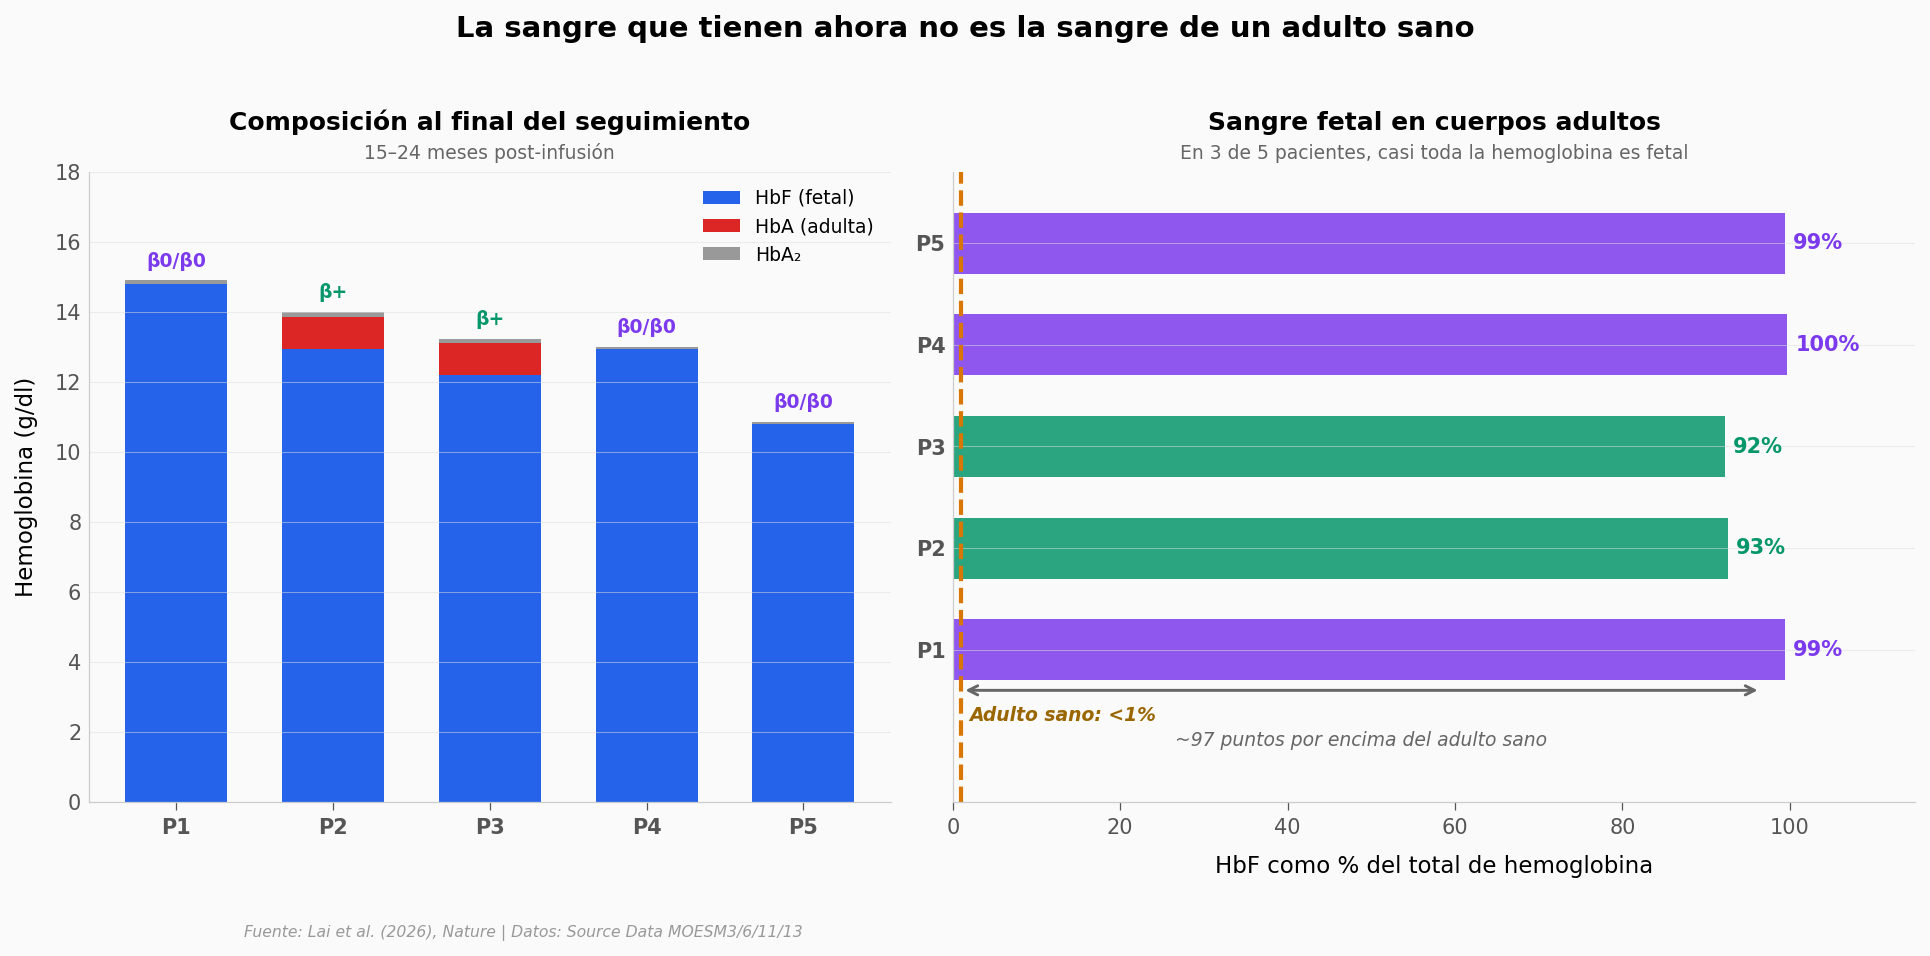

Composición final por paciente:
  P1 (β0/β0): HbF=14.81, HbA=0.00, total=14.90 g/dl  →  HbF=99% del total
  P2 (   β+): HbF=12.95, HbA=0.91, total=13.99 g/dl  →  HbF=93% del total
  P3 (   β+): HbF=12.20, HbA=0.91, total=13.23 g/dl  →  HbF=92% del total
  P4 (β0/β0): HbF=12.95, HbA=0.00, total=12.99 g/dl  →  HbF=100% del total
  P5 (β0/β0): HbF=10.80, HbA=0.00, total=10.87 g/dl  →  HbF=99% del total


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), gridspec_kw={'width_ratios': [1, 1.2]})

# ─── Panel izquierdo: stacked bar de composición Hb por paciente ───
ax = axes[0]
ult_hb = df_hb.sort_values('month').groupby('patient').last().reset_index()
pacientes = ult_hb.patient.tolist()
hbf_vals = ult_hb.hbf_g_dl.values
hba_vals = ult_hb.hba_g_dl.values
hba2_vals = ult_hb.hba2_g_dl.values

x_pos = np.arange(len(pacientes))
ax.bar(x_pos, hbf_vals, color=COLOR_HBF, label='HbF (fetal)', width=0.65)
ax.bar(x_pos, hba_vals, bottom=hbf_vals, color=COLOR_HBA, label='HbA (adulta)', width=0.65)
ax.bar(x_pos, hba2_vals, bottom=hbf_vals + hba_vals, color='#999999',
       label='HbA₂', width=0.65)

# Anotar el genotipo
for i, p in enumerate(pacientes):
    g = GENOTIPO[p]
    color_g = COLOR_BETA0 if g == 'β0/β0' else COLOR_BETA_PLUS
    ax.text(i, ult_hb.hb_total_g_dl.iloc[i] + 0.4, g,
            ha='center', fontsize=9, fontweight='bold', color=color_g)

ax.set_xticks(x_pos)
ax.set_xticklabels(pacientes, fontweight='bold')
ax.set_ylabel('Hemoglobina (g/dl)', fontsize=11)
ax.set_title('Composición al final del seguimiento',
             fontsize=12, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '15–24 meses post-infusión',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='center')
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.set_ylim(0, 18)

# ─── Panel derecho: HbF como % del total — comparación con adulto sano ───
ax = axes[1]
hbf_pct = (hbf_vals / ult_hb.hb_total_g_dl.values) * 100
colores_p = [COLOR_BETA0 if GENOTIPO[p] == 'β0/β0' else COLOR_BETA_PLUS for p in pacientes]

bars = ax.barh(x_pos, hbf_pct, color=colores_p, alpha=0.85, height=0.6)
for i, (p, v) in enumerate(zip(pacientes, hbf_pct)):
    ax.text(v + 1, i, f'{v:.0f}%',
            va='center', fontsize=10, fontweight='bold', color=colores_p[i])

# Línea de referencia: adulto sano
ax.axvline(x=HBF_ADULTO_SANO_PCT, color=COLOR_REF, linewidth=2, linestyle='--')
ax.text(HBF_ADULTO_SANO_PCT + 1, -0.7, f'Adulto sano: <{HBF_ADULTO_SANO_PCT:.0f}%',
        color='#996600', fontsize=9, fontweight='bold', style='italic')

# Flecha bidireccional mostrando la diferencia
ax.annotate('', xy=(hbf_pct.mean(), -0.4), xytext=(HBF_ADULTO_SANO_PCT, -0.4),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.4))
ax.text((hbf_pct.mean() + HBF_ADULTO_SANO_PCT)/2, -0.95,
        f'~{hbf_pct.mean():.0f} puntos por encima del adulto sano',
        ha='center', fontsize=9, color='#666666', style='italic')

ax.set_yticks(x_pos)
ax.set_yticklabels(pacientes, fontweight='bold')
ax.set_xlabel('HbF como % del total de hemoglobina', fontsize=11)
ax.set_title('Sangre fetal en cuerpos adultos',
             fontsize=12, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'En 3 de 5 pacientes, casi toda la hemoglobina es fetal',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='center')
ax.set_xlim(0, 115)
ax.set_ylim(-1.5, len(pacientes) - 0.3)

fig.suptitle('La sangre que tienen ahora no es la sangre de un adulto sano',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/composicion_final.png', dpi=200, bbox_inches='tight')
plt.show()

# Datos para la narrativa
print('Composición final por paciente:')
for p, hbf, hba, total in zip(pacientes, hbf_vals, hba_vals, ult_hb.hb_total_g_dl):
    pct = (hbf / total) * 100
    print(f'  {p} ({GENOTIPO[p]:>5}): HbF={hbf:.2f}, HbA={hba:.2f}, total={total:.2f} g/dl  →  HbF={pct:.0f}% del total')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El base editor convierte ~0% en ~62% de células editadas in vitro | ✅ | NT media 0,04% (DE 0,03), Editadas media 62,1% (DE 0,89). Cohen's dz pareado ≈ 69 (separación total entre grupos — las distribuciones no se solapan). Wilcoxon signed-rank unilateral p≈0,031. n=5 lotes pareados |
| La edición se mantiene en sangre periférica meses después | ✅ | Media 12 meses: 37,9% (mediana 34,7%). Rango post-3M: 26–54%. Curva plana, no decreciente |
| Los 5 pacientes dejaron transfusiones de sangre | ✅ | Mediana de tiempo a última transfusión: 18 días tras infusión. 5/5 pacientes |
| HbF subió ~31× desde baseline al año 1 | ✅ | Baseline media 0,41 g/dl → mes 12 media 12,77 g/dl. Ratio 31,1× |
| 3 pacientes (P1, P4, P5) sin β-globina endógena viven solo con HbF | ✅ | Genotipo β0/β0 confirmado por composición de globinas (β=NaN/0). HbA al final: 0,00 g/dl en los 3 |
| La terapia es segura | ⚠️ | 0 muertes y 0 cánceres en mediana 23 meses, **pero** N=5, single-arm, sin grupo control. Eventos adversos consistentes con busulfán mieloablativo (no triviales) |
| Esto reemplaza al trasplante alogénico | ❌ | El trial no compara contra otras terapias (Casgevy, lentiviral, alogénico). Hablar solo de "estos 5 pacientes", no de superioridad |

> **Limitaciones:**
> - **N=5 sin control:** no permite comparar magnitud de efecto contra otras terapias ni descartar regresión a la media.
> - **Mediana 23 meses:** seguimiento intermedio. Riesgos de seguridad a largo plazo (cánceres tardíos, reactivación de virus, off-target editing acumulado) no se pueden descartar.
> - **Contexto del busulfán:** la mieloablación previa es la misma de un trasplante. La novedad es la fuente de las células — no el procedimiento completo.
> - **In vitro vs in vivo:** la edición in vitro (62%) y la final en sangre (28–52%) no son la misma cosa. La caída es esperable: solo las células madre con el editor sobreviven y se replican.

## Ahora tú

Tres preguntas que los datos pueden responder:

**1.** ¿Cuál fue el primer mes en que cada paciente cruzó el umbral de 12 g/dl de hemoglobina total?
*Pista:* `df_hb[(df_hb.hb_total_g_dl >= 12) & (df_hb.patient == 'P1')].head(1)`.

**2.** ¿La edición en sangre periférica de mes 21 se mantiene cerca de la de mes 12 para los pacientes que llegaron a esa fecha?
*Pista:* `df_pbmc[df_pbmc.month.isin([12, 21])].pivot(index='patient', columns='month', values='editing_freq_pct')`.

**3.** ¿Qué pasaría si calculas la fracción de HbF del total para cada paciente en cada mes, y la graficas? ¿Cuándo cruzan el 90% de fetal?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿En qué momento cada paciente alcanzó el 50% de HbF como fracción de su Hb total?

df_hb_pct = df_hb.copy()
df_hb_pct['hbf_pct'] = (df_hb_pct.hbf_g_dl / df_hb_pct.hb_total_g_dl) * 100

print('Primer mes en que cada paciente cruza HbF ≥ 50% del total:\n')
for paciente in sorted(df_hb_pct.patient.unique()):
    sub = df_hb_pct[df_hb_pct.patient == paciente].sort_values('month')
    cruza = sub[sub.hbf_pct >= 50].head(1)
    if len(cruza):
        m = cruza.month.iloc[0]
        pct = cruza.hbf_pct.iloc[0]
        print(f'  {paciente} ({GENOTIPO[paciente]:>5}): mes {m:.0f} con HbF={pct:.1f}% del total')
    else:
        print(f'  {paciente}: nunca cruzó 50% en el seguimiento')

# Bonus: en qué mes cada paciente paró de tener HbA detectable (≤ 0.1 g/dl)
print('\nPrimer mes con HbA ≤ 0,1 g/dl (hemoglobina adulta indetectable):\n')
for paciente in sorted(df_hb.patient.unique()):
    sub = df_hb[df_hb.patient == paciente].sort_values('month')
    sin_hba = sub[sub.hba_g_dl <= 0.1].head(1)
    if len(sin_hba):
        print(f'  {paciente} ({GENOTIPO[paciente]:>5}): mes {sin_hba.month.iloc[0]:.0f}')
    else:
        m_min = sub.iloc[sub.hba_g_dl.idxmin() - sub.index[0]]
        print(f'  {paciente} ({GENOTIPO[paciente]:>5}): nunca llegó a 0,1 — mínimo en mes {m_min.month:.0f} con {m_min.hba_g_dl:.2f} g/dl')

Primer mes en que cada paciente cruza HbF ≥ 50% del total:

  P1 (β0/β0): mes 2 con HbF=80.9% del total
  P2 (   β+): mes 2 con HbF=62.9% del total
  P3 (   β+): mes 2 con HbF=70.7% del total
  P4 (β0/β0): mes 2 con HbF=75.8% del total
  P5 (β0/β0): mes 1 con HbF=53.4% del total

Primer mes con HbA ≤ 0,1 g/dl (hemoglobina adulta indetectable):

  P1 (β0/β0): mes 4
  P2 (   β+): nunca llegó a 0,1 — mínimo en mes 10 con 0.74 g/dl
  P3 (   β+): nunca llegó a 0,1 — mínimo en mes 18 con 0.77 g/dl
  P4 (β0/β0): mes 4
  P5 (β0/β0): mes 4


---

## Créditos

**Datos:** Source Data files MOESM3, MOESM6, MOESM11 y MOESM13 del paper original (Nature, abierto).
**Análisis:** Reproducible al 100% con los CSVs de este repositorio.
**Trial:** ClinicalTrials.gov [NCT06024876](https://clinicaltrials.gov/study/NCT06024876).
**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC BY 4.0.

## Fuentes

## Fuentes

**Paper**: [Clinical application of base editing for treating β-thalassaemia](https://doi.org/10.1038/s41586-026-10342-9)  
*Nature, 2026-04-08*

**Datos suplementarios**: [Source Data Fig. 1, Fig. 4, Extended Data Fig. 7, Extended Data Fig. 9 — Lai et al. 2026](https://www.nature.com/articles/s41586-026-10342-9#Sec)  
*Source Data files MOESM3/6/11/13*

**Trial**: [Phase 1 Clinical Trial of CS-101 (Base-Edited Autologous CD34+ Cells) for β-Thalassaemia](https://clinicaltrials.gov/study/NCT06024876)

*15 afirmaciones verificadas contra estas fuentes · consulta 2026-04-28*